In [50]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from pyomo.environ import *
from optimization_utils import *
from param_loader import METANET_Params
from simulation_utils import *
from eval_metrics import *
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
# print ipopt version
!ipopt --version

Ipopt 3.14.16 (Darwin x86_64), ASL(20160307)


In [40]:
def to_wallclock(tick_minutes, start_hour):
    labels = []
    for m in tick_minutes:
        total_minutes = start_hour * 60 + m
        h = int(total_minutes // 60) % 24
        mn = int(total_minutes % 60)
        labels.append(f"{h:02d}:{mn:02d}")
    return labels

In [41]:
# rho_hat = df["Density"]
# q_hat = df["Flow"]
# print(max(q_hat))
# C_i = np.mean(sorted(q_hat)[-5:])
# print("C_i", C_i)
# K = len(rho_hat)

real_data = True

if real_data:
    #### I-5 Data
    # q_hat = np.load("I5_400m_10s_16segments/flow_matrix_asm.npy") [120:,]
    # rho_hat = np.load("I5_400m_10s_16segments/density_matrix_asm.npy") [120:,]

    # lanes_per_bin = np.load("I5_400m_10s_16segments/lanes_per_bin.npy")
    # lane_mapping = {i: float(lanes_per_bin[i]) for i in range(len(lanes_per_bin))}

    # #### I-24 Data
    q_hat = np.load("data/flow_10sec_400m_1hr.npy")#[240:270, :]
    rho_hat = np.load("data/density_10sec_400m_1hr.npy")#[240:270, :]

    lane_map = np.load("data/lane_mapping.npy")
    lane_mapping = {i: float(lane_map[i+1]) for i in range(len(lane_map)-2)}

    ramp_mapping = {"on_ramps": np.load("data/on_ramp_mapping.npy")[1:-1], "off_ramps": np.load("data/off_ramp_mapping.npy")[1:-1]}
    print(ramp_mapping)
    print(lane_mapping)

    #### I-35W Data
    # q_hat = np.load("data/i35_southbound/i35_sb5_flow_10sec_400m.npy")#[int(2.2*60*6): int(3.2*60*6)]  # 2-3 hours
    # rho_hat = np.load("data/i35_southbound/i35_sb5_density_10sec_400m.npy")#[int(2.2*60*6): int(3.2*60*6)]

    # lane_map = np.load("data/i35_southbound/lanes_sb5.npy")
    # lane_mapping = {i: float(lane_map[i]) for i in range(len(lane_map))}

    # ramp_mapping = {"on_ramps": np.load("data/i35_southbound/on_ramps_sb5.npy"), "off_ramps": np.load("data/i35_southbound/off_ramps_sb5.npy")}
    # print(ramp_mapping)
    # print(lane_mapping)
else:
    q_hat = np.load("data/q_synthetic.npy") #np.load("data/flow_10sec_400m_1hr.npy")
    # print(np.max(q_hat))
    rho_hat = np.load("data/p_synthetic.npy") #np.load("data/density_10sec_400m_1hr.npy")

v_hat = q_hat / rho_hat
print(rho_hat.shape)
flattened_q_hat = q_hat.flatten()
print(max(flattened_q_hat))
flattened_rho_hat = rho_hat.flatten()
C_i = np.mean(np.sort(flattened_q_hat)[-5:])
print("C_i", C_i)
K = len(flattened_rho_hat)
print("K", K)

{'on_ramps': array([False,  True, False, False, False, False, False, False, False,
       False,  True, False, False,  True]), 'off_ramps': array([False, False, False, False, False, False, False, False, False,
        True, False,  True, False, False])}
{0: 4.0, 1: 4.0, 2: 4.0, 3: 4.3539391649542445, 4: 5.0, 5: 5.0, 6: 5.0, 7: 5.0, 8: 4.860748562409972, 9: 4.0, 10: 4.0, 11: 4.050664946063771, 12: 4.507098142428658, 13: 4.0}
(360, 16)
6773.200199999966
C_i 6718.716719999977
K 5760


In [42]:
rho_hat = np.where(rho_hat == 0.0, 1e-3, rho_hat)
q_hat = np.where(q_hat == 0.0, 1e-3, q_hat)

In [43]:
if not real_data:
    print(rho_hat.shape)
    print(q_hat.shape)
    downstream_density = np.full(rho_hat.shape[0], 0)
    data_inflow = np.array([5500 if i in range(20, 20 + 90) else 4000 for i in range(rho_hat.shape[0])])

    np.save("data/downstream_density_synthetic.npy", downstream_density)
    np.save("data/inflow_synthetic.npy", data_inflow)


    plt.figure(figsize=(12, 6))
    # plt.subplot(2, 1, 1)
    # plt.plot(rho_hat[:, 0], label="Density")
    plt.plot(downstream_density, label="Downstream Density")
    plt.legend()
    plt.subplot(2, 1, 2)
    # plt.plot(q_hat[:, 0], label="Flow")
    plt.plot(data_inflow, label="Upstream Inflow")
    plt.legend()
    plt.show()


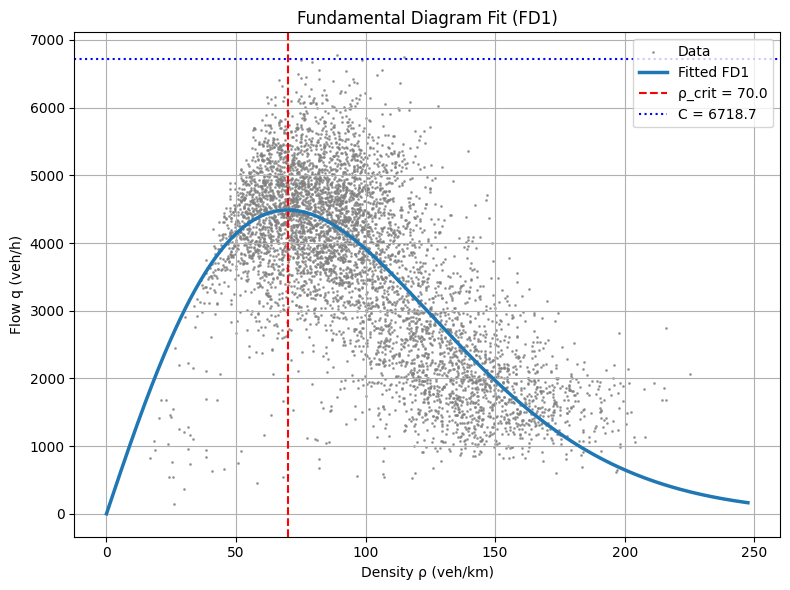

{'rho_crit': 69.95774856112287, 'V_free': 114.25733457721735, 'a': 1.7319895914943968, 'C': np.float64(6718.716719999977), 'Q_fd1': <function fit_fd1.<locals>.Q_fd1 at 0x10eca4f60>}


In [44]:
params = fit_fd1(flattened_rho_hat, flattened_q_hat)
print(params)

In [45]:
print(f"Bounds on rho: {np.min(rho_hat)} to {np.max(rho_hat)}")
print(f"Bounds on q: {np.min(q_hat)} to {np.max(q_hat)}")
print(f"Bounds on v: {np.min(v_hat)} to {np.max(v_hat)}")

Bounds on rho: 16.6199985 to 225.06999625000026
Bounds on q: 139.07610000000858 to 6773.200199999966
Bounds on v: 3.114799360447148 to 102.5494591064967


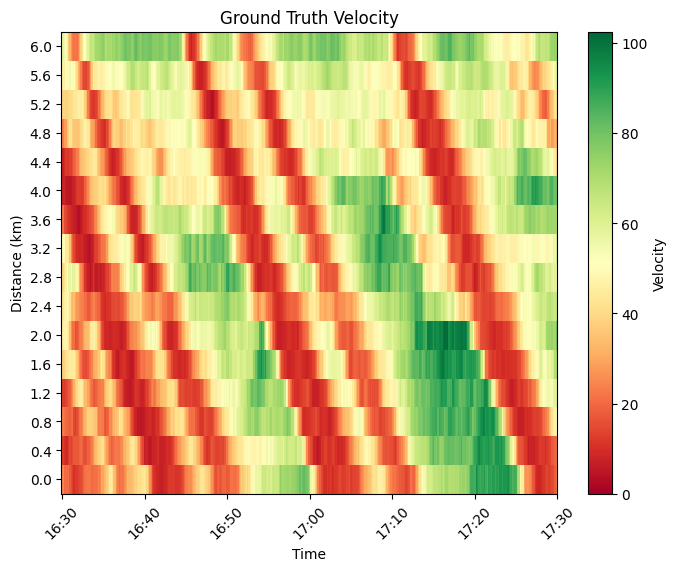

In [46]:
start_wallclock_time = 16.5
plt.figure(figsize=(8, 6))
plt.imshow(v_hat.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none", vmin=0)
plt.colorbar(label="Velocity")

# Convert time steps to wall clock time
time_steps = v_hat.shape[0]+1
time_ticks = list(range(0, time_steps, int(time_steps / 6)))
# Correct - each step is 10 seconds = 10/60 minutes
tick_minutes = [i * 10 / 60 for i in time_ticks]
time_labels = to_wallclock(tick_minutes, start_wallclock_time)

# Convert space steps to km
space_steps = v_hat.shape[1]
space_labels = [f"{(i * 400) / 1000:.1f}" for i in range(0, space_steps, int(space_steps / 10))]
space_ticks = list(range(0, space_steps, int(space_steps / 10)))

plt.xticks(time_ticks, time_labels, rotation=45)
plt.yticks(space_ticks, space_labels)

plt.title("Ground Truth Velocity")
plt.xlabel("Time")
plt.ylabel("Distance (km)")
plt.show()

In [47]:
print(v_hat.shape)

(360, 16)


In [52]:
T = 10 / 3600
l = 0.4
num_calibrated_segments = v_hat.shape[1] - 2
include_ramping = False
varylanes = False
smoothing = True

In [53]:
random.seed(1)
np.random.seed(1)
# lane_mapping = np.array([4 if i < num_calibrated_segments - 4 else 2 for i in range(num_calibrated_segments)])
RESULTS_DIR = "itsc_final/OCP_logtest" #calibration_results_i35/shorter_nb_robust"
#"calibration_results/synthetic_test" if not real_data else "calibration_results/robust_S10_mean" #"calibration_results_i35/test_sb2"
# boundary_conditions = {
#     "initial_flow": data_inflow,
#     "downstream_density": downstream_density,
# }

#robust_opt_params = RobustOptConfig(S=5, bc_noise_percent=0.0001, seed=2, objective_mode="mean")
print(np.shape(ramp_mapping["on_ramps"]))
print(np.shape(ramp_mapping["off_ramps"]))
print(len(lane_mapping))
print(num_calibrated_segments)
start = time.time()
results = run_calibration(
    rho_hat,
    q_hat,
    T,
    l,
    num_calibrated_segments=num_calibrated_segments,
    # sep_boundary_conditions=boundary_conditions,
    varylanes=varylanes,
    #lane_mapping={0:4, 1:4, 24, 3:4.5, 4:5, 5:5, 6:5, 7:5, 8:5, 9:4, 10:4, 11:4, 12:4.5, 13:4},
    include_ramping=include_ramping,
    lane_mapping=lane_mapping,
    ramp_mapping=ramp_mapping,
    smoothing=smoothing,
    constraint_tol=1e-12,
    warmstart= None, #"calibration_results/robust_S10_0001",
    robust_opt=None,
    time_varying_ramps=False,
    fixed_inflows=None
)

print("Calibration took", time.time() - start, "seconds")

(14,)
(14,)
14
14
Ipopt 3.14.16: max_iter=20000
acceptable_constr_viol_tol=1e-12
constr_viol_tol=1e-12


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:    79008
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    73819

Total number of variables............................:    10164
                     variables with only lower bounds:        0
                variables with lower and upper bounds:    10164
                     variables with only upper bound

In [53]:
# Save initial and downstream conditions
import os

if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)
    
np.save(f"{RESULTS_DIR}/upstream_flow.npy", smooth_inflow(q_hat[:, 0]) if smoothing else q_hat[:, 0])
np.save(f"{RESULTS_DIR}/downstream_density.npy", smooth_inflow(rho_hat[:, -1]) if smoothing else rho_hat[:, -1])

In [54]:
tau_array = results["tau"]
K_array = results["K"]
eta_high_array = results["eta_high"]
rho_crit_array = results["rho_crit"]
v_free_array = results["v_free"]
a_array = results["a"]
num_lanes_array = results["num_lanes"]
# if include_ramping:
    # gamma_array = results["gamma"]
beta_array = results["beta"]
r_inflow_array = results["r_inflow"]

In [55]:
# r_array = np.zeros(num_calibrated_segments)
# beta_array = np.zeros(num_calibrated_segments)
# print(beta_array.shape)
# print(r_inflow_array.shape)

In [56]:
# Save everything
tau_array = results["tau"]
K_array = results["K"]
eta_high_array = results["eta_high"]
rho_crit_array = results["rho_crit"]
v_free_array = results["v_free"]
a_array = results["a"]
num_lanes_array = results["num_lanes"]
# if include_ramping:
    # gamma_array = results["gamma"]
beta_array = results["beta"]
r_inflow_array = results["r_inflow"]
v_pred_array = results["v_pred"]
rho_pred_array = results["rho_pred"]
q_array = v_pred_array * rho_pred_array

np.save(f"{RESULTS_DIR}/tau.npy", tau_array)
np.save(f"{RESULTS_DIR}/K.npy", K_array)
np.save(f"{RESULTS_DIR}/eta_high.npy", eta_high_array)
np.save(f"{RESULTS_DIR}/rho_crit.npy", rho_crit_array)
np.save(f"{RESULTS_DIR}/v_free.npy", v_free_array)
np.save(f"{RESULTS_DIR}/a.npy", a_array)
np.save(f"{RESULTS_DIR}/num_lanes.npy", num_lanes_array)
np.save(f"{RESULTS_DIR}/q_pred.npy", q_array)
np.save(f"{RESULTS_DIR}/v_pred.npy", v_pred_array)
np.save(f"{RESULTS_DIR}/rho_pred.npy", rho_pred_array)
# np.save("r_array.npy", r_array)
# if include_ramping:
    # np.save("gamma_array.npy", gamma_array)
np.save(f"{RESULTS_DIR}/beta_array.npy", beta_array)
np.save(f"{RESULTS_DIR}/r_inflow_array.npy", r_inflow_array)

(720, 31)
(720, 31)
(720, 33)
31


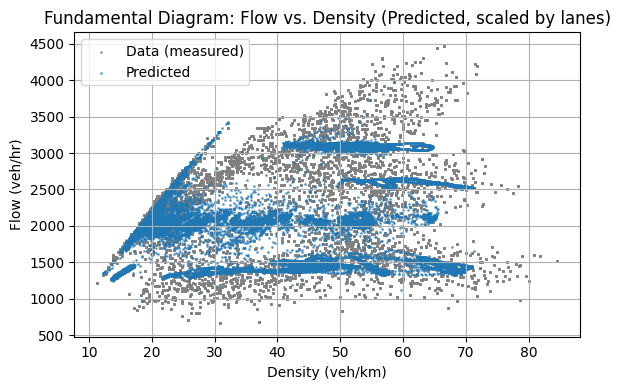

In [57]:
import matplotlib.pyplot as plt

# # Collect scaled predictions across all segments
all_rho_pred = rho_pred_array

print(all_rho_pred.shape)
all_v_pred = v_pred_array
all_q_pred = all_rho_pred * all_v_pred


# Stack predictions
all_rho_pred = np.hstack(all_rho_pred)
all_q_pred = np.hstack(all_q_pred)
all_v_pred = np.hstack(all_v_pred)

print(v_pred_array.shape)
print(v_hat.shape)
print(len(tau_array))

# assert np.all(v_pred_array[0,:] == v_hat[0,1:-1])
# assert np.all(v_pred_array[0,:] == v_hat[0,1:-1])
# Plot
plt.figure(figsize=(6, 4))
plt.scatter(rho_hat, q_hat, color="gray", alpha=0.7, s=1, label="Data (measured)")
plt.scatter(all_rho_pred, all_q_pred, alpha=0.6, s=1, label="Predicted")
plt.xlabel("Density (veh/km)")
plt.ylabel("Flow (veh/hr)")
plt.title("Fundamental Diagram: Flow vs. Density (Predicted, scaled by lanes)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

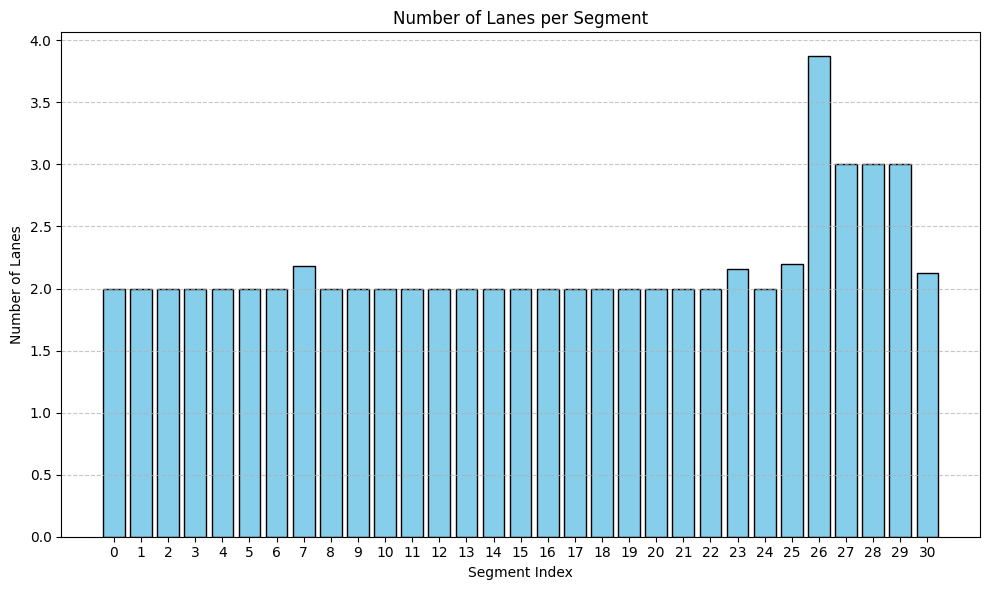

In [58]:
plt.figure(figsize=(10, 6))
plt.bar(
    np.arange(len(num_lanes_array)), num_lanes_array, color="skyblue", edgecolor="black"
)

plt.xlabel("Segment Index")
plt.ylabel("Number of Lanes")
plt.title("Number of Lanes per Segment")
plt.xticks(np.arange(len(num_lanes_array)))  # show all indices
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

In [28]:
# Read parameters from RESULTS_DIR

RESULTS_DIR = "ga_calibration_results/trials2500"


tau_array = np.load(f"{RESULTS_DIR}/tau.npy")
K_array = np.load(f"{RESULTS_DIR}/K.npy")
eta_high_array = np.load(f"{RESULTS_DIR}/eta_high.npy")
v_free_array = np.load(f"{RESULTS_DIR}/v_free.npy")
rho_crit_array = np.load(f"{RESULTS_DIR}/rho_crit.npy")
a_array = np.load(f"{RESULTS_DIR}/a.npy")

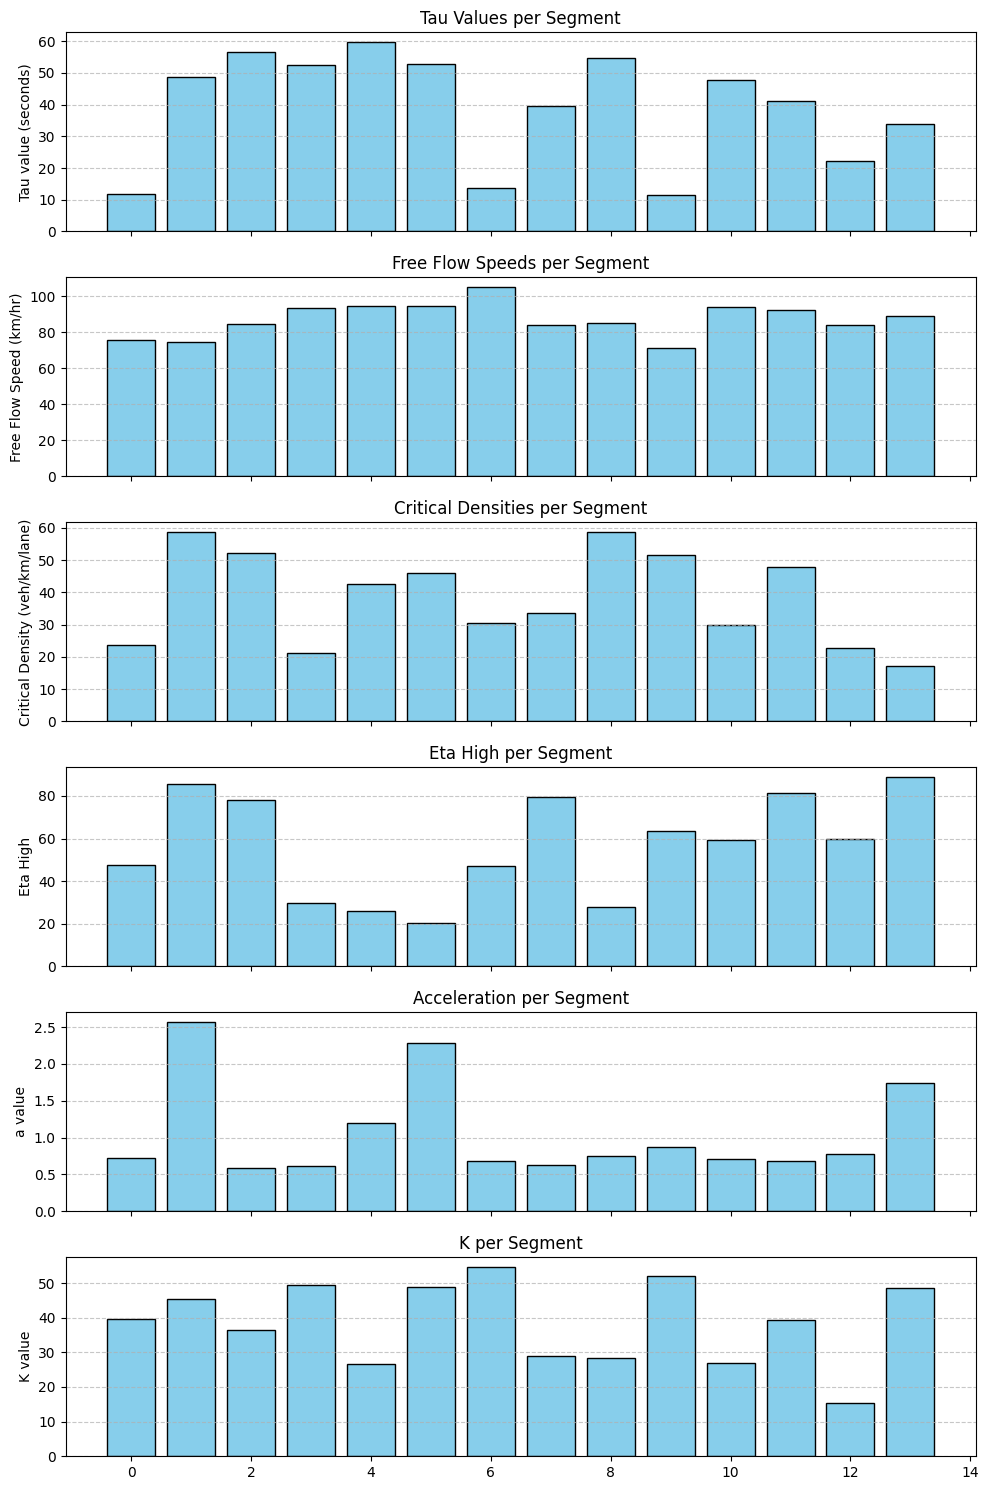

In [8]:
# Plot parameters in bar chart, show default value
fig, axes = plt.subplots(6, 1, figsize=(10, 15), sharex=True)
axes[0].bar(
    np.arange(len(tau_array)), tau_array*3600, color="skyblue", edgecolor="black"
)

axes[0].set_ylabel("Tau value (seconds)")
axes[0].set_title("Tau Values per Segment")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

axes[1].bar(
    np.arange(len(v_free_array)), v_free_array, color="skyblue", edgecolor="black"
)
axes[1].set_ylabel("Free Flow Speed (km/hr)")
axes[1].set_title("Free Flow Speeds per Segment")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

axes[2].bar(
    np.arange(len(rho_crit_array)), rho_crit_array, color="skyblue", edgecolor="black"
)
axes[2].set_ylabel("Critical Density (veh/km/lane)")
axes[2].set_title("Critical Densities per Segment")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

axes[3].bar(
    np.arange(len(eta_high_array)), eta_high_array, color="skyblue", edgecolor="black"
)
axes[3].set_ylabel("Eta High")
axes[3].set_title("Eta High per Segment")
axes[3].grid(axis="y", linestyle="--", alpha=0.7)

axes[4].bar(
    np.arange(len(a_array)), a_array, color="skyblue", edgecolor="black"
)
axes[4].set_ylabel("a value")
axes[4].set_title("Acceleration per Segment")
axes[4].grid(axis="y", linestyle="--", alpha=0.7)

axes[5].bar(
    np.arange(len(K_array)), K_array, color="skyblue", edgecolor="black"
)
axes[5].set_ylabel("K value")
axes[5].set_title("K per Segment")
axes[5].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

In [743]:
# if include_ramping:
#     plt.figure(figsize=(10, 6))
#     plt.bar(
#         np.arange(len(r_inflow_array)), r_inflow_array, color="skyblue", edgecolor="black"
#     )

#     plt.xlabel("Segment Index")
#     plt.ylabel("Inflow")
#     plt.title("Inflow per Segment")
#     plt.xticks(np.arange(len(num_lanes_array)))  # show all indices
#     plt.grid(axis="y", linestyle="--", alpha=0.7)

#     plt.tight_layout()

plt.plot(r_inflow_array[:, 1])

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

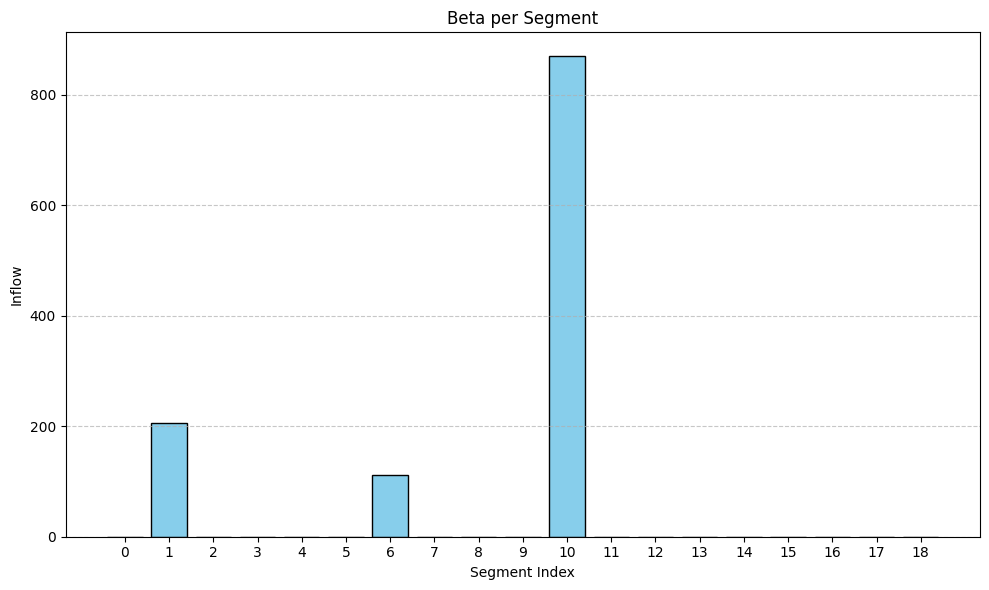

In [103]:
if include_ramping:
    plt.figure(figsize=(10, 6))
    plt.bar(np.arange(len(r_inflow_array)), r_inflow_array, color="skyblue", edgecolor="black")

    plt.xlabel("Segment Index")
    plt.ylabel("Inflow")
    plt.title("Beta per Segment")
    plt.xticks(np.arange(len(num_lanes_array)))  # show all indices
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()

In [10]:
# print(all_v_pred.shape)
q_array = rho_pred_array * v_pred_array
print("rho mape", mape(rho_hat[:, 1:-1], rho_pred_array))
print("q mape", mape(q_hat[:, 1:-1], q_array))
print("v mape", mape(v_hat[:, 1:-1], v_pred_array))
print("----------------")
print("rho rmse", rmse(rho_hat[:, 1:-1], rho_pred_array))
print("q rmse", rmse(q_hat[:, 1:-1], q_array))
print("v rmse", rmse(v_hat[:, 1:-1], v_pred_array))

NameError: name 'rho_pred_array' is not defined

In [29]:
print("Simulating with calibrated parameters...")
# stop printing in scientific notation
RESULTS_DIR = "ga_calibration_results"
np.set_printoptions(suppress=True)
# RESULTS_DIR = "robust_mpc_calibration_results/S5/control_h_10/params_1"
#RESULTS_DIR = "calibration_results_i35/shorter_nb"
#RESULTS_DIR = "mpc_calibration_results/control_h_360/params_1"

# RESULTS_DIR = "calibration_results/i24_11_30_rl_posttrain_2"
# RESULTS_DIR = "itsc_final/calibration_results/OCP"
# RESULTS_DIR = "itsc_final/mpc_calibration_results/control_h_90"

T=10/3600
l=0.4
num_calibrated_segments = rho_hat.shape[1] - 2
# num_lanes_array = np.load(f"{RESULTS_DIR}/num_lanes.npy")

# Scale densities per lane for simulation
# num_lanes_array = np.load(f"{RESULTS_DIR}/num_lanes.npy")
scaled_rho_hat = rho_hat[:, 1:-1] / lane_map[1:-1]#np.array(num_lanes_array)


# if smoothing boundary conditions
# print(num_lanes_array)
downstream_density = smooth_inflow(rho_hat[:, -1]) / lane_map[1:-1][-1]
data_inflow = smooth_inflow(q_hat[:, 0])
# downstream_density = rho_hat[:, -1] / num_lanes_array[-1]
# data_inflow = q_hat[:, 0]
# print(downstream_density[250:270])
# print(rho_hat[250:270, -1])

print(np.where(scaled_rho_hat < 0))
# Sim requires tuple of initial conditions: density, velocity, inflow, and queue
init_traffic_state = (scaled_rho_hat[0, :], v_hat[0, 1:-1], data_inflow[0], 0)
# print(RESULTS_DIR)

params = METANET_Params(path=RESULTS_DIR, num_segments=num_calibrated_segments).get_params()
#mpc_params = METANET_Params(path="itsc_final/mpc_calibration_results", control_h=1, num_timesteps=360).get_params()

# print(params['tau'].shape)
# print(params['beta'])
# print(params['r'])
rho_sim, v_sim, _, tts_sim = run_metanet_sim(
    T, 
    l, 
    init_traffic_state,
    data_inflow,
    downstream_density,
    params,
    vsl_speeds=None,
    lanes=lane_mapping, #{i: num_lanes_array[i] for i in range(num_calibrated_segments)},
    plotting=True,
    real_data=True
)

Simulating with calibrated parameters...
(array([], dtype=int64), array([], dtype=int64))


In [132]:
# good_params = METANET_Params(path=RESULTS_DIR, num_segments=num_calibrated_segments).get_params()
# bad_params = METANET_Params(path='calibration_results', num_segments=num_calibrated_segments).get_params()
# #check if params are different
# print(bad_params['r'])
# print(good_params['r'])
# for key in bad_params:
#     if isinstance(bad_params[key], dict):
#         for subkey in bad_params[key]:
#             if not np.array_equal(bad_params[key][subkey], good_params[key][subkey]):
#                 print(f"Parameter {key}[{subkey}] differs between bad and good params.")
#     else:
#         if not np.array_equal(bad_params[key], good_params[key]):
#             print(f"Parameter {key} differs between bad and good params.")


Pred shape: (720, 31)
True shape: (720, 31)
Max true density: 84.46564404289127


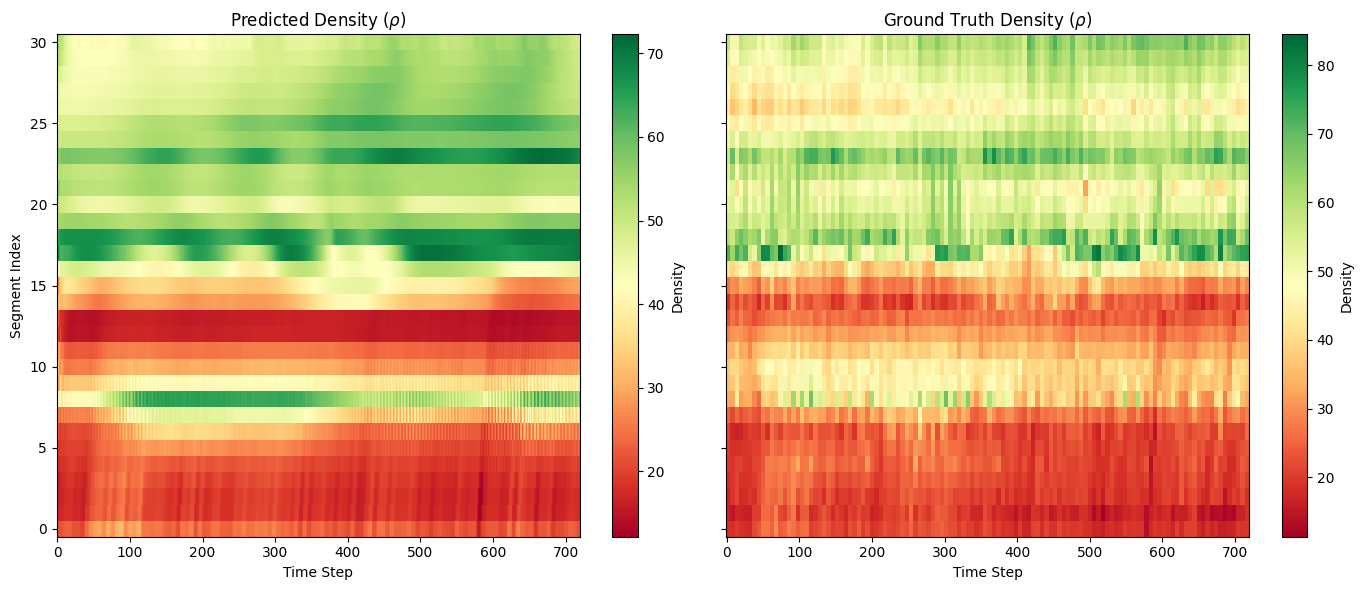

In [62]:
rho_plot_pred = rho_pred_array
rho_plot_true = rho_hat[:, 1:-1]

print("Pred shape:", rho_plot_pred.shape)
print("True shape:", rho_plot_true.shape)
print("Max true density:", np.max(rho_plot_true))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Prediction ---
im0 = axes[0].imshow(
    rho_plot_pred.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Segment Index")
axes[0].set_title("Predicted Density ($\\rho$)")
fig.colorbar(im0, ax=axes[0], label="Density")

# --- Ground Truth ---
im1 = axes[1].imshow(
    rho_plot_true.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[1].set_xlabel("Time Step")
axes[1].set_title("Ground Truth Density ($\\rho$)")
fig.colorbar(im1, ax=axes[1], label="Density")

plt.tight_layout()
plt.show()

Pred shape: (360, 14)
True shape: (360, 14)
Max true density: 102.5494591064967


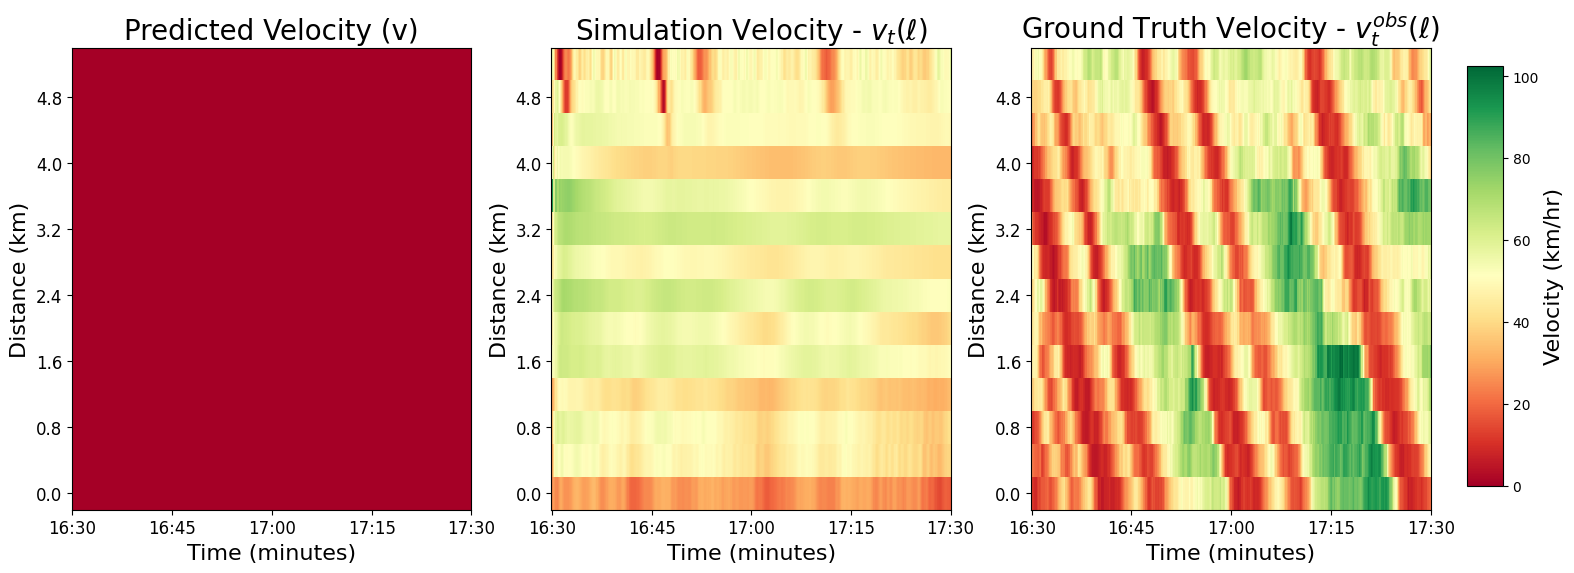

In [30]:
# print(v_pred_array[0, :])
# print(v_pred_array[1, :])
v_plot_pred = np.zeros_like(v_hat[:, 1:-1])#np.load(f"{RESULTS_DIR}/v_pred.npy")
v_plot_true = v_hat[:, 1:-1]

print("Pred shape:", v_plot_pred.shape)
print("True shape:", v_plot_true.shape)
print("Max true density:", np.max(v_plot_true))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Compute common color scale ---
vmin = min(
    np.min(v_plot_pred),
    np.min(v_sim),
    np.min(v_plot_true),
)
vmax = max(
    np.max(v_plot_pred),
    np.max(v_sim),
    np.max(v_plot_true),
)

# --- Prediction ---
im0 = axes[0].imshow(
    v_plot_pred.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Segment Index")
axes[0].set_title("Predicted Velocity (v)")

# --- Simulation ---
im1 = axes[1].imshow(
    v_sim.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_xlabel("Time Step")
axes[1].set_title("Simulation Velocity - $v_t(\\ell)$", fontsize=20)

# --- Ground Truth ---
im2 = axes[2].imshow(
    v_plot_true.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[2].set_xlabel("Time Step")
axes[2].set_title(
    "Ground Truth Velocity - $v^{obs}_t(\\ell)$",
    fontsize=20,
)

# ---- One shared colorbar in its own axis ----
# Make room on the right for the colorbar
fig.subplots_adjust(right=0.88)

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im0, cax=cbar_ax)
cbar.set_label("Velocity (km/hr)", fontsize=16)

# Convert x label to minutes
for ax in axes:
    ax.set_xlabel("Time (minutes)")

# Convert x ticks to minutes
num_time_steps = v_plot_pred.shape[0]+1
time_step_indices = np.arange(0, num_time_steps, max(1, num_time_steps // 4))
time_step_labels = [f"{(i * T * 60):.0f}" for i in time_step_indices]
time_minutes = time_step_indices * T * 60
time_step_labels = to_wallclock(time_minutes, start_wallclock_time)
for ax in axes:
    ax.set_xticks(time_step_indices)
    ax.set_xticklabels(time_step_labels)

# Convert y axis to kilometers
for ax in axes:
    num_segments = v_plot_pred.shape[1]
    segment_indices = np.arange(0, num_segments, max(1, num_segments // 6))
    segment_labels = [f"{(i * l):.1f}" for i in segment_indices]
    ax.set_yticks(segment_indices)
    ax.set_yticklabels(segment_labels)
    ax.set_ylabel("Distance (km)")

# label font size
for ax in axes:
    ax.title.set_fontsize(20)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)
    ax.tick_params(axis='both', which='major', labelsize=12)    

plt.show()


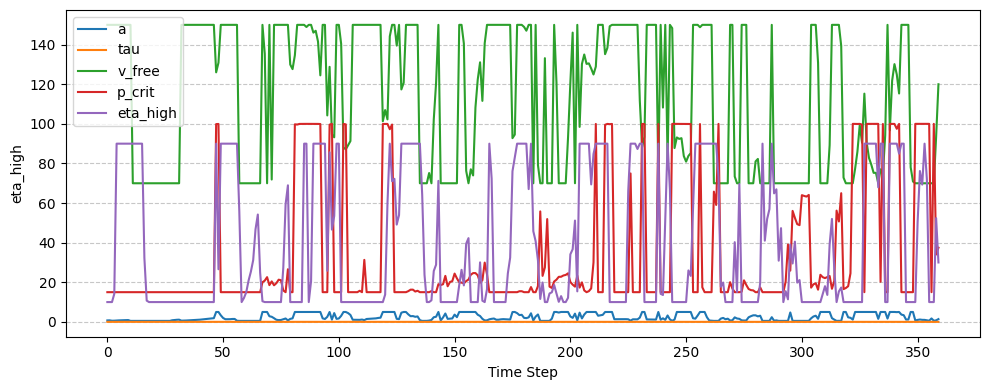

In [68]:
plt.figure(figsize=(10, 4))
for param in ['a', 'tau', 'v_free', 'p_crit', 'eta_high']:
    param_array = mpc_params[param][:, 6]

    plt.plot(np.arange(len(param_array)), param_array, label=param)
    plt.xlabel("Time Step")
    plt.ylabel(param)
    # plt.title(f"{param} per Segment")
    # plt.xticks(np.arange(len(param_array)))  # show all indices
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

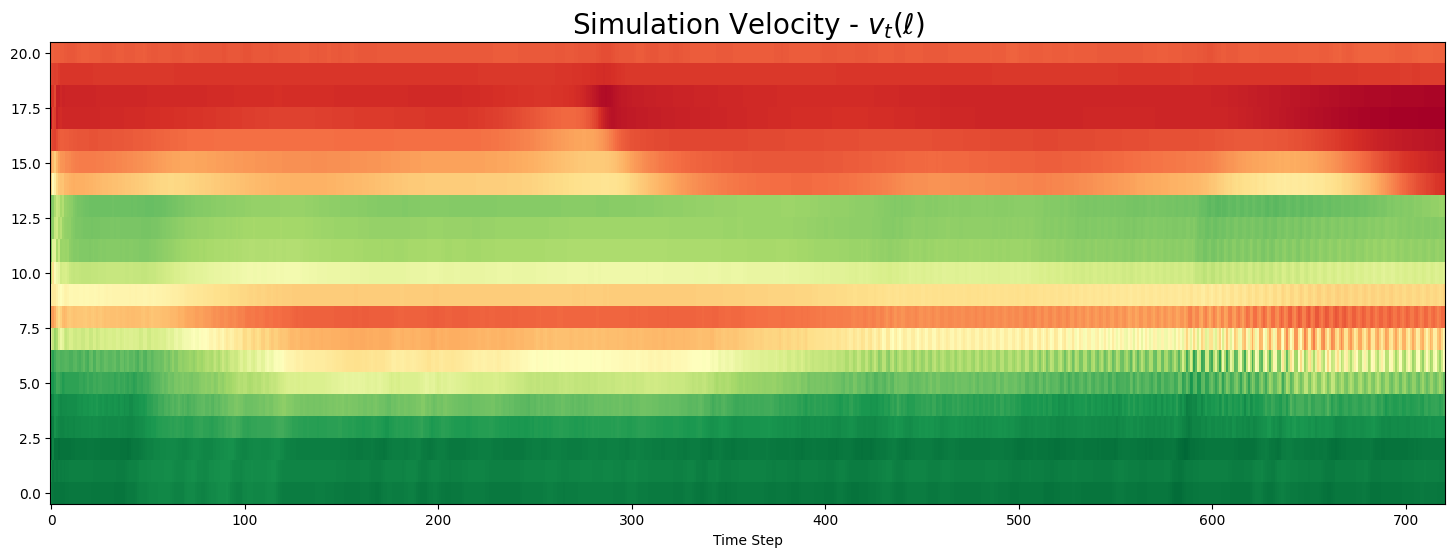

In [44]:
# Plot only v_sim
# --- Simulation ---
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

im1 = axes.imshow(
    v_sim.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
)
axes.set_xlabel("Time Step")
axes.set_title("Simulation Velocity - $v_t(\\ell)$", fontsize=20)

plt.show()

In [50]:
np.save(f"{RESULTS_DIR}/v_sim.npy", v_sim)

In [36]:
print("rho mape", mape(rho_hat[:, 1:-1], rho_sim[0:-1, :] * np.array(lane_map[1:-1])))
print("v mape", mape(v_hat[:, 1:-1], v_sim[0:-1, :]))
print("----------------")
print("rho rmse", rmse(rho_hat[:, 1:-1], rho_sim[0:-1, :] * np.array(lane_map[1:-1])))
print("v rmse", rmse(v_hat[:, 1:-1], v_sim[0:-1, :]))

rho mape 43.51639529940845
v mape 103.55706122124546
----------------
rho rmse 49.44861677205327
v rmse 25.784517156991463


In [37]:
# test_dir = RESULTS_DIR #"itsc_final/calibration_results/OCP" #"calibration_results/test/robust_current_end" #"mpc_calibration_results/1_of_1"
test_dir = "ga_calibration_results"

params =  METANET_Params(path=test_dir, num_segments=num_calibrated_segments).get_params()
# num_lanes_array = np.load(os.path.join(test_dir, "num_lanes.npy"))


epsilons = [1e-13, 1e-7, 1e-4, 0.01, 0.1, 1, 5]
eval_results = eval_robustness_static(v_hat[:, 1:-1], params, data_inflow, downstream_density, init_traffic_state, 
                                    lanes=lane_mapping, T=T, l=l, percent_noises=epsilons, rho_gt=rho_hat[:, 1:-1],
                                    plotting_dir=test_dir, save_results=True)

# eval_results = eval_robustness_dynamic(v_hat[:, 1:-1], 1, "mpc_calibration_results", data_inflow, downstream_density, 
#                                             init_traffic_state, T=T, l=l, percent_noises=epsilons, save_results=True)
    


J_cost for true simulation: 41950150.814406425
Robustness error with 1e-13% noise level on inflows: worst-case = 103.55706122124546 / mean = 103.55706122124543
J_cost for true simulation: 41950150.814406425
Robustness error with 1e-07% noise level on inflows: worst-case = 103.55706122297872 / mean = 103.55706122120228
J_cost for true simulation: 41950150.814406425
Robustness error with 0.0001% noise level on inflows: worst-case = 103.55706295450679 / mean = 103.55706117806734
J_cost for true simulation: 41950150.814406425
Robustness error with 0.01% noise level on inflows: worst-case = 103.55723454589076 / mean = 103.55705690166178
J_cost for true simulation: 41950150.814406425
Robustness error with 0.1% noise level on inflows: worst-case = 103.55879433226454 / mean = 103.55701786405756
J_cost for true simulation: 41950150.814406425
Robustness error with 1% noise level on inflows: worst-case = 103.57438171595388 / mean = 103.5566120818952
J_cost for true simulation: 41950150.814406425


In [194]:
print(mape(v_hat[:, 1:-1], v_sim[0:-1, :]))

35.13568281362052


/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_22725/674838133.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


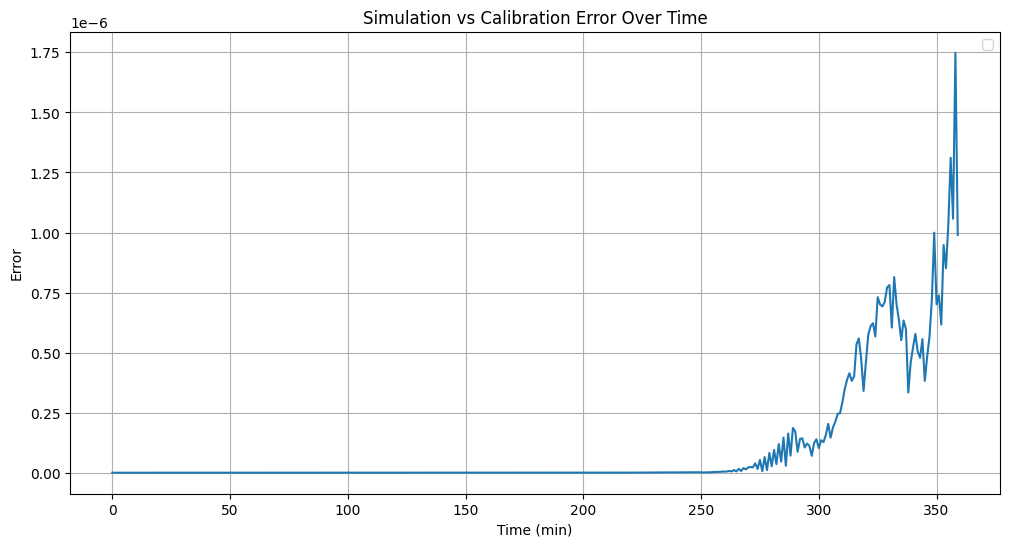

In [195]:
# plot error over time between prediction and simulation
plt.figure(figsize=(12, 6))
plt.plot(np.abs(v_plot_pred - v_sim[0:-1, :]).mean(axis=1))
plt.xlabel('Time (min)')
plt.ylabel('Error')
plt.title('Simulation vs Calibration Error Over Time')
plt.legend()
plt.grid()
plt.savefig(RESULTS_DIR + '/error_propogate_lanes_ramping.png')
plt.show()

/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_2210/1933283574.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


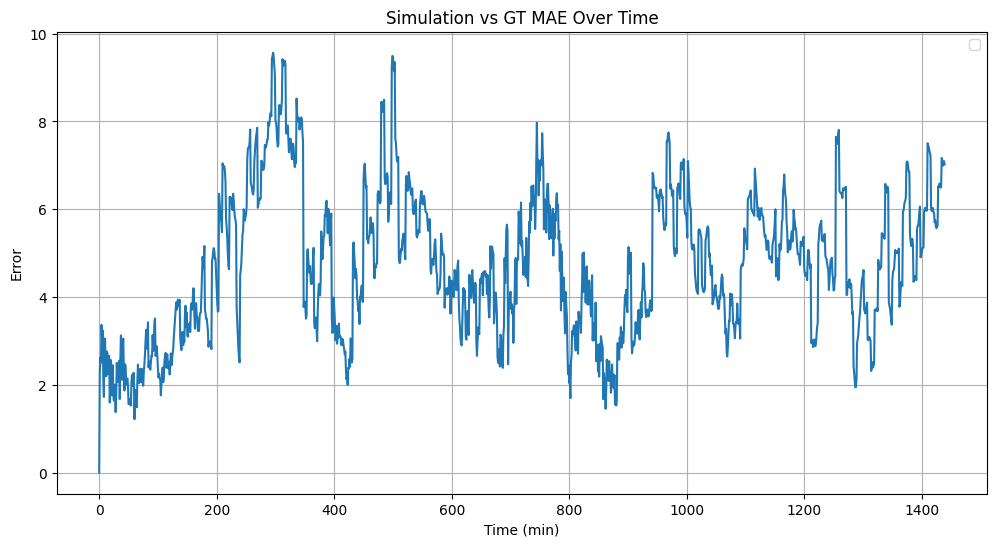

In [30]:
# plot error over time between prediction and simulation
plt.figure(figsize=(12, 6))
plt.plot(np.abs(v_hat[:, 1:-1] - v_sim[0:-1, :]).mean(axis=1))
plt.xlabel('Time (min)')
plt.ylabel('Error')
plt.title('Simulation vs GT MAE Over Time')
plt.legend()
plt.grid()
plt.savefig(RESULTS_DIR + '/error_propogate_lanes_ramping.png')
plt.show()

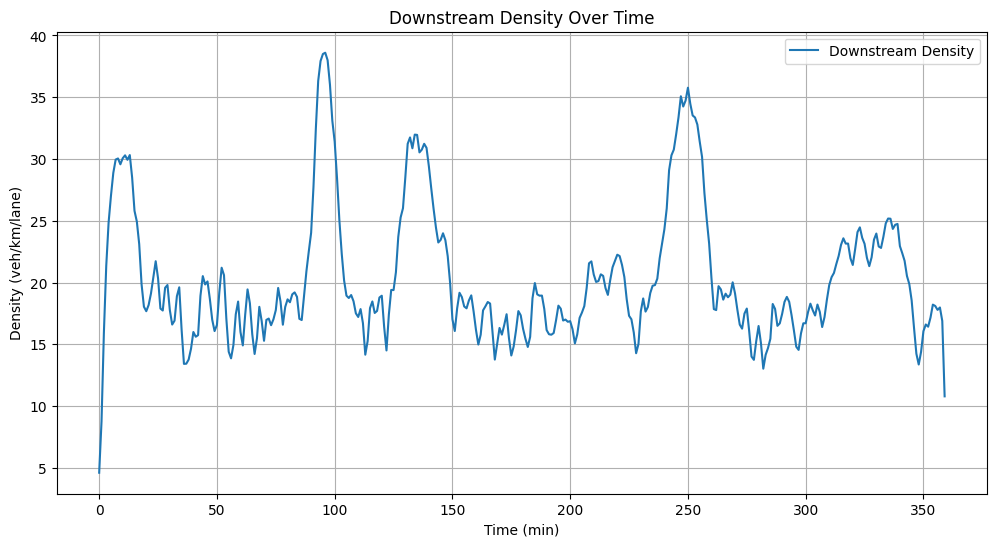

In [750]:
#plot downstream density over time and inflow over time
plt.figure(figsize=(12, 6))
plt.plot(downstream_density, label='Downstream Density')
plt.xlabel('Time (min)')
plt.ylabel('Density (veh/km/lane)')
plt.title('Downstream Density Over Time')
plt.legend()
plt.grid()
plt.show()



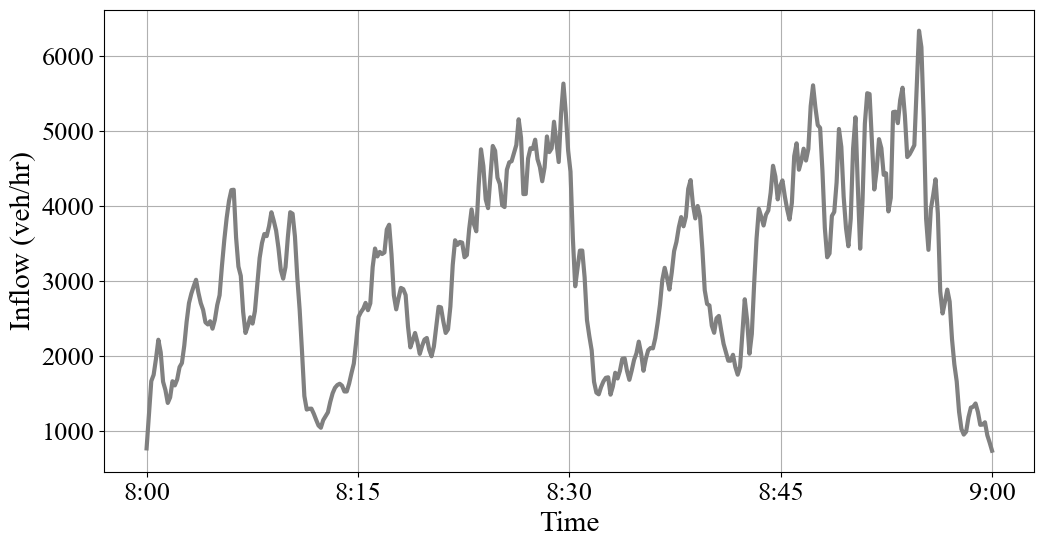

In [826]:
# Plot inflow over time
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

g_fontsize = 21
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": "Times New Roman",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "text.usetex": False,
    "font.size": g_fontsize,
    "axes.labelsize": g_fontsize,
    "xtick.labelsize": g_fontsize - 2,
    "ytick.labelsize": g_fontsize - 2,
    "legend.fontsize": g_fontsize - 1,
})

plt.figure(figsize=(12, 6))
plt.plot(data_inflow, label='Inflow', linewidth=3, color='gray')

plt.xlabel('Time')
plt.ylabel('Inflow (veh/hr)')

# Assume data_inflow covers exactly 8:00 AM to 9:00 AM
n = len(data_inflow)

tick_positions = np.linspace(0, n - 1, 5)
tick_labels = ['8:00', '8:15', '8:30', '8:45', '9:00']

plt.xticks(tick_positions, tick_labels)
plt.grid()
plt.savefig('inflow_over_time.pdf', bbox_inches='tight')
plt.show()

Pred shape: (360, 14)
True shape: (360, 14)
Max true density: 6749.992799999934


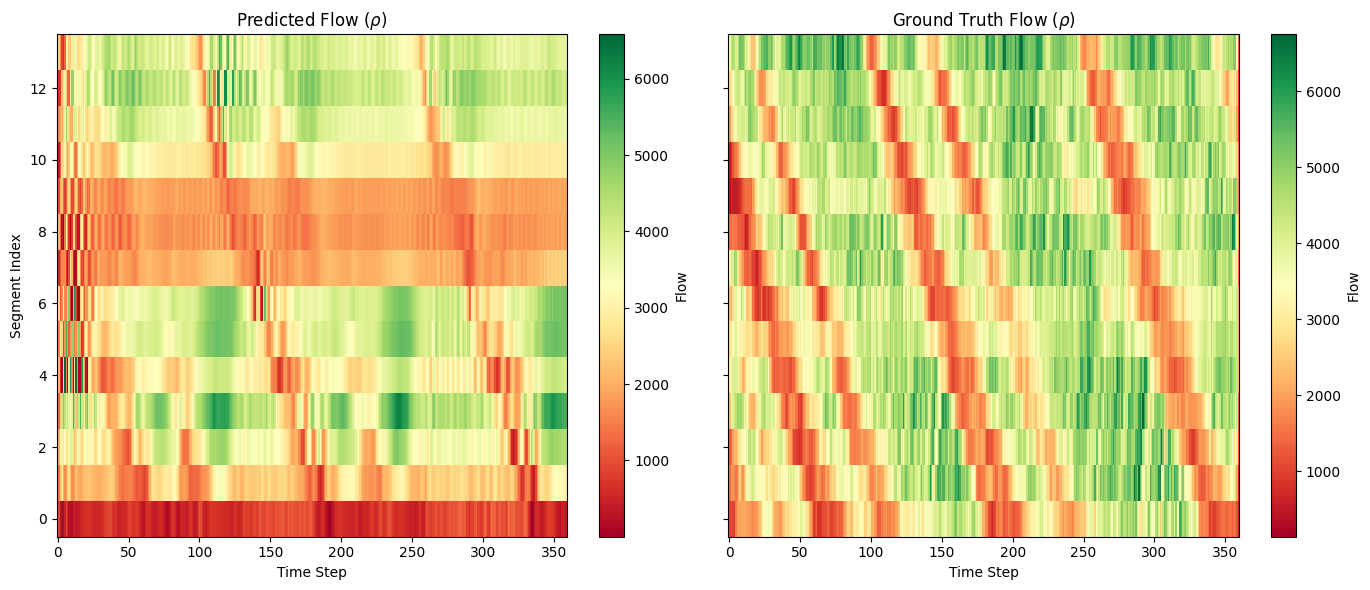

In [ ]:
rho_plot_pred = rho_pred_array * v_pred_array
rho_plot_true = q_hat[:, 1:-1]

print("Pred shape:", rho_plot_pred.shape)
print("True shape:", rho_plot_true.shape)
print("Max true density:", np.max(rho_plot_true))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Prediction ---
im0 = axes[0].imshow(
    rho_plot_pred.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Segment Index")
axes[0].set_title("Predicted Flow ($\\rho$)")
fig.colorbar(im0, ax=axes[0], label="Flow")

# --- Ground Truth ---
im1 = axes[1].imshow(
    rho_plot_true.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"
)
axes[1].set_xlabel("Time Step")
axes[1].set_title("Ground Truth Flow ($\\rho$)")
fig.colorbar(im1, ax=axes[1], label="Flow")

plt.tight_layout()
plt.show()

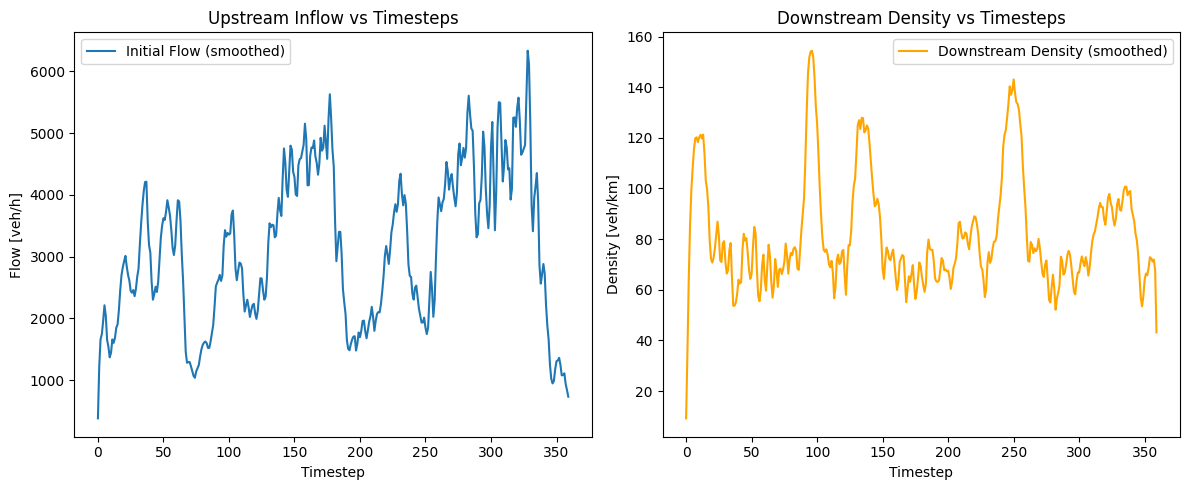

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def smooth_inflow(inflow, window_size=2):
    kernel = np.ones(window_size) / window_size
    smoothed = np.apply_along_axis(
        lambda m: np.convolve(m, kernel, mode="same"), axis=0, arr=inflow
    )
    return smoothed


# Example input arrays (replace with your real q_hat and rho_hat)
# timesteps = 100
# q_hat = np.random.uniform(500, 1000, size=(timesteps, 5))   # flow [veh/h]
# rho_hat = np.random.uniform(10, 50, size=(timesteps, 5))    # density [veh/km]

# Apply smoothing
initial_flow = smooth_inflow(q_hat[:, 0:1])  # upstream inflow
downstream_density = smooth_inflow(rho_hat[:, -1:])  # downstream density

# Plotting
plt.figure(figsize=(12, 5))

# Flow vs timesteps
plt.subplot(1, 2, 1)
plt.plot(initial_flow, label="Initial Flow (smoothed)")
plt.xlabel("Timestep")
plt.ylabel("Flow [veh/h]")
plt.title("Upstream Inflow vs Timesteps")
plt.legend()

# Density vs timesteps
plt.subplot(1, 2, 2)
plt.plot(downstream_density, color="orange", label="Downstream Density (smoothed)")
plt.xlabel("Timestep")
plt.ylabel("Density [veh/km]")
plt.title("Downstream Density vs Timesteps")
plt.legend()

plt.tight_layout()
plt.show()

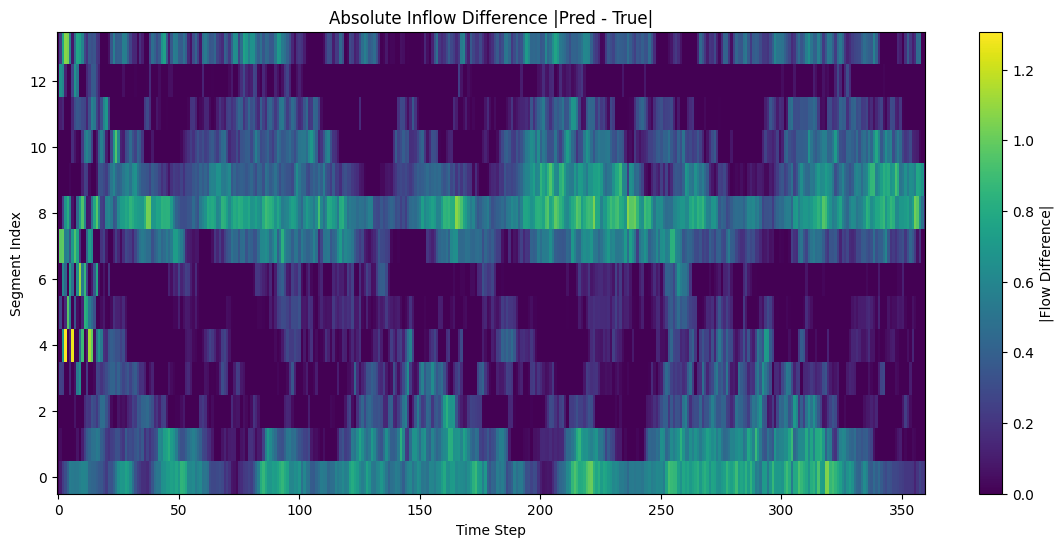

In [ ]:
def get_velocity_heatmap(v_hat, v_pred, q_hat, q_pred, rho_hat, rho_pred):
    shortened_v_hat = v_hat[:, 1:-1]
    shortened_rho_hat = rho_hat[:, 1:-1]
    shortened_q_hat = q_hat[:, 1:-1]
    # Determine some set of 3 scalars for each of q, rho, v to make a unified map
    v_diff = (shortened_v_hat - v_pred) / np.max(shortened_v_hat)
    rho_diff = (shortened_rho_hat - rho_pred) / np.max(shortened_rho_hat)
    q_diff = (shortened_q_hat - q_pred) / np.max(shortened_q_hat)

    diff = v_diff + rho_diff + q_diff
    fig, ax = plt.subplots(figsize=(14, 6))

    im = ax.imshow(
        diff.T,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        interpolation="none",
        vmin=0,
    )
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Segment Index")
    ax.set_title("Absolute Inflow Difference |Pred - True|")
    fig.colorbar(im, ax=ax, label="|Flow Difference|")
    plt.show()


get_velocity_heatmap(v_hat, v_pred_array, q_hat, q_array, rho_hat, rho_pred_array)